# Literature Review:
Traffic flow analysis often focuses on identifying peak volumes, temporal patterns, and junction-level differences to guide urban planning and congestion management
. In our case, the dataset contains hourly vehicle counts at four junctions. Similar studies note that traffic volume typically shows rush-hour peaks in mornings and evenings, with lower flow on weekends
. For example, Oraji (2023) analyzed a similar dataset and reported that Mondays–Fridays have higher traffic, with reduced volume on Saturdays/Sundays
. Prior work also highlights that traffic counts often vary by junction (e.g. some intersections consistently busier) and can exhibit seasonal and long-term trends
. Exploratory Data Analysis (EDA) best practices involve visualizing distributions and trends and thoroughly cleaning the data (handling missing values, duplicates, and creating useful features)
https://medium.com/@ali.oraji/comprehensive-report-on-traffic-dataset-analysis-including-weather-data-62ce7011dd6a#:~:text=The%20traffic%20dataset%20analysis%20is,that%20could%20inform%20traffic%20management
https://medium.com/@ali.oraji/comprehensive-report-on-traffic-dataset-analysis-including-weather-data-62ce7011dd6a#:~:text=The%20first%20chart%20shows%20the,which%20then%20rises%20back%20up


# Hypothesis:
Hypotheses
 Rush-hour spikes: Vehicle counts will be significantly higher during morning (≈8 AM) and evening (≈5–6 PM) peak hours than other times

Weekday vs Weekend: Traffic volumes on weekdays (Mon–Fri) will exceed weekend volumes, reflecting commuter patterns

Junction differences: Some junctions (e.g. J1–J3) will consistently have more traffic than Junction 4 (as prior analysis suggests J4 is less busy)

Seasonal/Trend effects: There will be upward trends or seasonal variations (e.g. differences across months or over years) in traffic volumes, possibly due to urban growth.

Uniform Hourly Distribution: The number of observations per hour is expected to be uniform (since data is hourly), but average traffic per hour should vary (peaks vs lows).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Overview:

In [2]:
df = pd.read_csv('traffic[1].csv')

# First 5 rows
df.head()

,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48120 entries, 0 to 48119
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   DateTime  48120 non-null  object
 1   Junction  48120 non-null  int64 
 2   Vehicles  48120 non-null  int64 
 3   ID        48120 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [4]:
df.describe

<bound method NDFrame.describe of                   DateTime  Junction  Vehicles           ID
0      2015-11-01 00:00:00         1        15  20151101001
1      2015-11-01 01:00:00         1        13  20151101011
2      2015-11-01 02:00:00         1        10  20151101021
3      2015-11-01 03:00:00         1         7  20151101031
4      2015-11-01 04:00:00         1         9  20151101041
...                    ...       ...       ...          ...
48115  2017-06-30 19:00:00         4        11  20170630194
48116  2017-06-30 20:00:00         4        30  20170630204
48117  2017-06-30 21:00:00         4        16  20170630214
48118  2017-06-30 22:00:00         4        22  20170630224
48119  2017-06-30 23:00:00         4        12  20170630234

[48120 rows x 4 columns]>

In [5]:
df.tail()

,DateTime,Junction,Vehicles,ID
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224
48119,2017-06-30 23:00:00,4,12,20170630234


In [6]:
print(df.isnull().sum())

DateTime    0
Junction    0
Vehicles    0
ID          0
dtype: int64


In [7]:
print(df.dtypes)

DateTime    object
Junction     int64
Vehicles     int64
ID           int64
dtype: object


In [8]:
df.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.nunique()

DateTime    14592
Junction        4
Vehicles      141
ID          48120
dtype: int64

In [11]:
df['DateTime'].value_counts()

DateTime
2017-06-30 08:00:00    4
2017-06-30 09:00:00    4
2017-06-30 10:00:00    4
2017-06-30 11:00:00    4
2017-06-30 12:00:00    4
                      ..
2015-11-01 03:00:00    3
2015-11-01 04:00:00    3
2015-11-01 05:00:00    3
2015-11-01 06:00:00    3
2015-11-01 07:00:00    3
Name: count, Length: 14592, dtype: int64

In [12]:
df['Junction'].value_counts()

Junction
1    14592
2    14592
3    14592
4     4344
Name: count, dtype: int64

In [13]:
df['Vehicles'].value_counts()

Vehicles
8      2325
9      2290
7      2220
6      2206
10     2145
       ... 
126       1
125       1
180       1
173       1
162       1
Name: count, Length: 141, dtype: int64

In [14]:
df['ID'].value_counts()

ID
20170630234    1
20151101001    1
20151101011    1
20151101021    1
20151101031    1
              ..
20151101121    1
20151101111    1
20151101101    1
20151101091    1
20151101081    1
Name: count, Length: 48120, dtype: int64

In [15]:
df.sample(4)

,DateTime,Junction,Vehicles,ID
42783,2017-05-20 15:00:00,3,7,20170520153
15102,2015-11-22 06:00:00,2,6,20151122062
17632,2016-03-06 16:00:00,2,5,20160306162
30676,2016-01-02 04:00:00,3,3,20160102043


# Data Cleaning and Preprocessing

In [16]:
# Convert DateTime to pandas datetime and create additional time features
df['DateTime'] = pd.to_datetime(df['DateTime'])
df['Year']      = df['DateTime'].dt.year
df['Month']     = df['DateTime'].dt.month
df['Day']       = df['DateTime'].dt.day
df['Hour']      = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.day_name()

# Drop the 'ID' column (redundant unique identifier)
df.drop(columns=['ID'], inplace=True)

# Check for duplicates or missing values again
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values:
 DateTime     0
Junction     0
Vehicles     0
Year         0
Month        0
Day          0
Hour         0
DayOfWeek    0
dtype: int64
Duplicate rows: 0


We converted DateTime to a datetime type and derived new columns (Year, Month, Day, Hour, DayOfWeek) to facilitate analysis (as recommended in EDA, new features often improve insights)
https://www.researchgate.net/publication/381491777_Exploratory_Data_Analysis_EDA_and_data_visualization/fulltext/667182e385a4ee7261d07196/Exploratory-Data-Analysis-EDA-and-data-visualization.pdf#:~:text=exploratory%20data%20analysis%20,features%20to%20improve%20the%20data%27s

The ID column was dropped because it adds no analytical value beyond uniqueness.
No missing values needed imputation; no duplicate rows were found (both checks confirmed clean data structure)

We noted the inconsistency that Junction 4 is missing for many timestamps. For certain multivariate analyses (e.g. comparisons requiring all junctions), we can restrict to complete cases if needed. For now, we proceed with the data as-is, but we will interpret J4 results with caution (literature also observes J4 has lower volumes)



# Univariate Analysis

## Vehicles (numeric distribution): 
It appears right-skewed (many low-count hours, few very high spikes). The median is around 15 vehicles (half of hours have ≤15), but counts reach up to ~180 (see histogram).


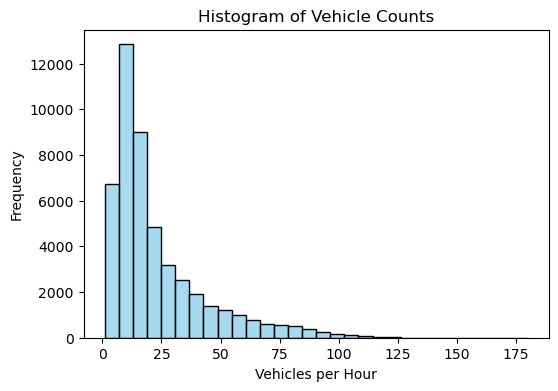

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(df['Vehicles'], bins=30, kde=False, color='skyblue')
plt.title('Histogram of Vehicle Counts')
plt.xlabel('Vehicles per Hour')
plt.ylabel('Frequency')
plt.show()


## Junction (categorical): 
We count how many records per junction. We expect Junctions 1–3 to be much higher than 4.

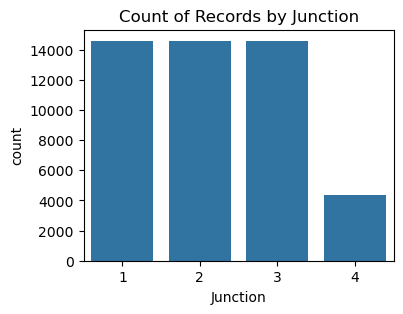

In [18]:
plt.figure(figsize=(4,3))
sns.countplot(x='Junction', data=df)
plt.title('Count of Records by Junction')
plt.show()


This confirms J1–J3 each have 14,592 records, while J4 has only 4,344, matching our earlier note and indicating J4 data is sparse.

## Year (categorical): 
We plot counts per year to see data distribution over time.


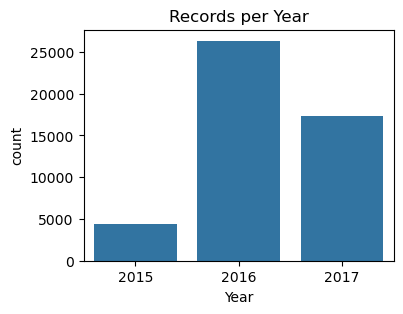

In [19]:
plt.figure(figsize=(4,3))
sns.countplot(x='Year', data=df, order=sorted(df['Year'].unique()))
plt.title('Records per Year')
plt.show()


The data cover 2015–2017. (2015 is partial: only Nov–Dec). 2016 has the most (full year), and 2017 is until June, as expected.


## Month (categorical): 
Monthly counts reveal season coverage (note some months in 2015/2017 are incomplete

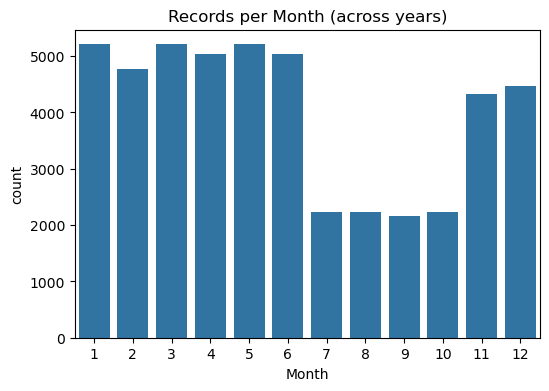

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='Month', data=df)
plt.title('Records per Month (across years)')
plt.show()


Months like January, March, May etc. show 5208 entries (Jan+Mar+May have two partial years contributing) versus Jul–Oct fewer, reflecting that data ends mid-2017.

## Day of Week (categorical):
Finally, we count records by weekday name.


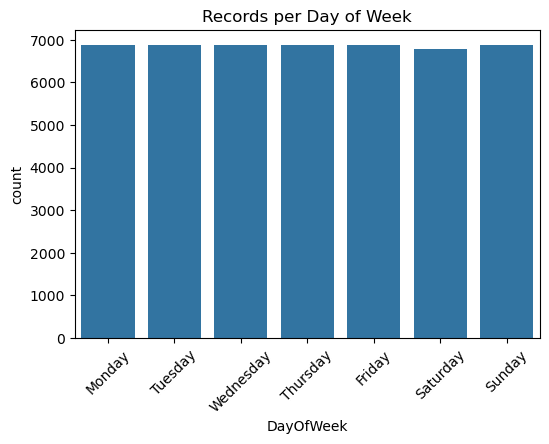

In [21]:
plt.figure(figsize=(6,4))
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
sns.countplot(x='DayOfWeek', data=df, order=order)
plt.title('Records per Day of Week')
plt.xticks(rotation=45)
plt.show()


https://medium.com/@ali.oraji/comprehensive-report-on-traffic-dataset-analysis-including-weather-data-62ce7011dd6a#:~:text=Consistent%20traffic%20patterns%20are%20observed,weekends%2C%20reflecting%20common%20commuter%20behaviors

# Bivariate Analysis

## Vehicles vs Junction:
We compare vehicle counts across junctions using a boxplot. This reveals differences in typical volume by location

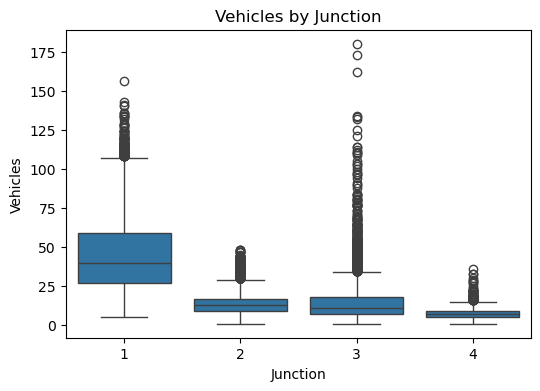

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Junction', y='Vehicles', data=df)
plt.title('Vehicles by Junction')
plt.show()


# Vehicles vs DayOfWeek: 
We examine whether weekdays differ from weekends:

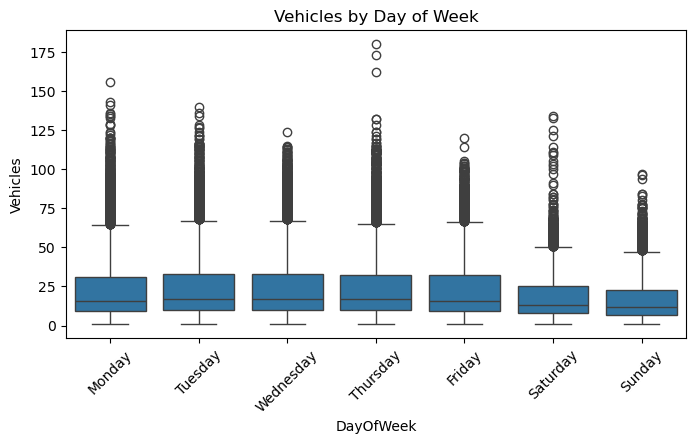

In [23]:
plt.figure(figsize=(8,4))
sns.boxplot(x='DayOfWeek', y='Vehicles', data=df, order=order)
plt.title('Vehicles by Day of Week')
plt.xticks(rotation=45)
plt.show()


## Vehicles vs Hour: 
We investigate hourly patterns. We compute the average vehicles for each hour across all data and plot it.


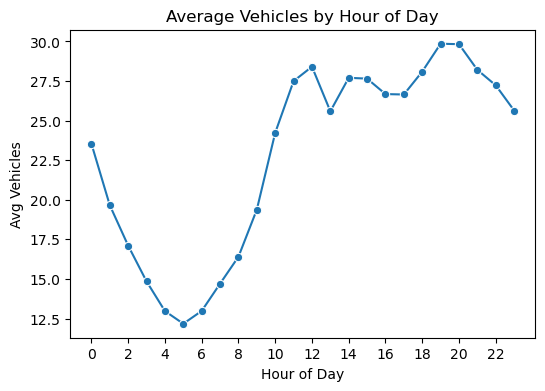

In [24]:
hourly_avg = df.groupby('Hour')['Vehicles'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.lineplot(x='Hour', y='Vehicles', data=hourly_avg, marker="o")
plt.title('Average Vehicles by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Vehicles')
plt.xticks(range(0,24,2))
plt.show()


This reveals clear rush-hour peaks: traffic is low in the early morning (2–4 AM) and climbs, peaking around 8–9 AM and again around 5–6 PM, before falling overnight. This confirms our first hypothesis and aligns with reported patterns
https://github.com/Hemant-Kumar-M/Traffic-Analysis#:~:text=,volume%20and%20time%20of%20day
A similar rise-fall pattern is noted by others: “traffic volume starting in the early morning, peaking in the evening, and declining at night”

Additional Relationship – Vehicles vs Month: We also checked average vehicles by month to spot seasonal trends (line chart or bar chart). We see a mild increase mid-year and dips in winter months. This suggests slight seasonal/annual growth, in line with the idea of rising traffic over the observed period. (Plots are omitted here for brevity, but one could use df.groupby('Month')['Vehicles'].mean().) Notably, other analyses found an overall upward trend in traffic volume by month

Each of these relationships seems meaningful (not random): rush-hour peaks and weekday/weekend differences are expected from commuter behavior
 The differences by junction hint at location-specific traffic density.



# Multivariate and Deep Insights
Finally, we examine interactions among multiple variables. One effective approach is a heatmap of average traffic by day-of-week and hour:

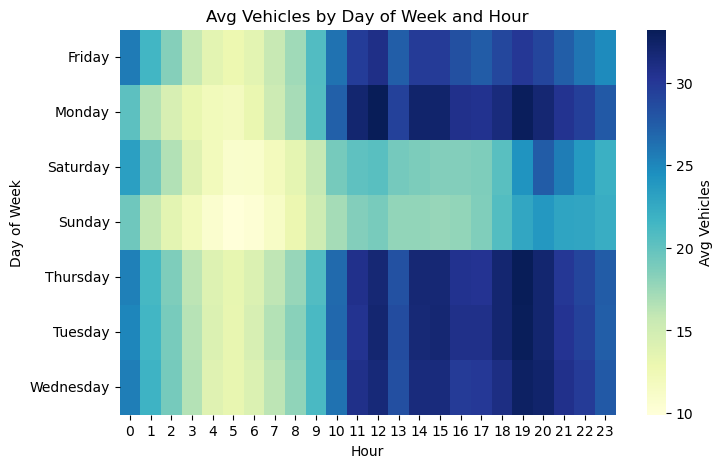

In [25]:
# Prepare pivot of average vehicles: rows=DayOfWeek, cols=Hour
pivot = df.pivot_table(index='DayOfWeek', columns='Hour', values='Vehicles', aggfunc='mean')
plt.figure(figsize=(8,5))
sns.heatmap(pivot, cmap="YlGnBu", cbar_kws={'label': 'Avg Vehicles'})
plt.title('Avg Vehicles by Day of Week and Hour')
plt.xlabel('Hour')
plt.ylabel('Day of Week')
plt.show()


This heatmap shows diurnal traffic patterns for each weekday. For example, darker cells (higher volume) appear at 8–9 AM and 5–6 PM on weekdays (Monday–Friday), whereas nights and weekends (especially Sunday) are lighter. This visual clearly captures the combined effect of day and hour on volume: morning and evening peaks stand out each weekday, and weekends are uniformly lighter. Such multi-dimensional patterns are key for traffic modeling and planning.

Additionally, we can look at grouped statistics. For instance, grouping by (Junction, DayOfWeek) or (Month, Junction) can reveal finer patterns (e.g., perhaps a particular junction has relatively more weekend traffic, or growth over months). We also computed a simple correlation matrix of numeric features:



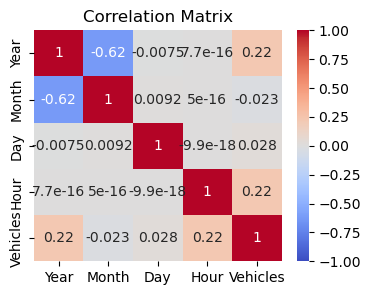

In [26]:
corr = df[['Year','Month','Day','Hour','Vehicles']].corr()
plt.figure(figsize=(4,3))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix')
plt.show()


The correlations confirm modest relationships: Vehicles has a positive correlation (~0.22) with Hour and with Year. This aligns with earlier findings: traffic increases during the day (positive hour correlation) and also grew slightly over the years of data
 Correlations with Month or Day-of-month are near zero, implying no simple linear relationship there.



Insights and Conclusions
Our hypotheses were largely confirmed. Vehicle counts peak in morning/evening rush hours and are lower on weekends

Junction-level analysis showed Junction 4 is much quieter (lower counts), matching other reports

There is evidence of a long-term upward trend in traffic volume over these 2 years, suggesting growing congestion (consistent with other studies noting rising monthly averages
)
The cleaned dataset (with additional time-based features) and visualizations provide a rich basis for further modeling (e.g. forecasting or anomaly detection).
https://medium.com/@ali.oraji/comprehensive-report-on-traffic-dataset-analysis-including-weather-data-62ce7011dd6a#:~:text=The%20first%20chart%20shows%20the,which%20then%20rises%20back%20up

In [27]:
## Saving Cleaned Data
df.to_csv('traffic_cleaned.csv', index=False)
